In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [20]:
hours = np.tile(np.arange(24), 1000)
demand = 15 + 8 * np.sin(2 * np.pi * (hours - 7) / 24) + np.random.normal(0, 1.2, 24000)
pd.DataFrame({'hour': hours, 'demand': np.round(demand, 2)}).to_csv('cyclic_feature_dataset.csv', index=False)

df = pd.read_csv("cyclic_feature_dataset.csv")
print('first 5 rows:\n', df.head())

X1 = df[['hour']]
y = df['demand']

df['hour_sin'] = np.sin(2 * np.pi * X1 / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * X1 / 24.0)

X2 = df[['hour_sin', 'hour_cos']]

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model2 = LinearRegression()

model1.fit(X1_train, y_train)
model2.fit(X2_train, y_train)

y_pred1 = model1.predict(X1_test)
y_pred2 = model2.predict(X2_test)

mse1 = mean_squared_error(y_test, y_pred1)
mse2 = mean_squared_error(y_test, y_pred2)

print(f"without cyclic encoding, MSE: {mse1}")
print(f"with cyclic encoding,    MSE: {mse2}")

first 5 rows:
    hour  demand
0     0    6.58
1     1    7.34
2     2    6.53
3     3    6.73
4     4    9.60
without cyclic encoding, MSE: 30.48891756287498
with cyclic encoding,    MSE: 1.4896257341944277


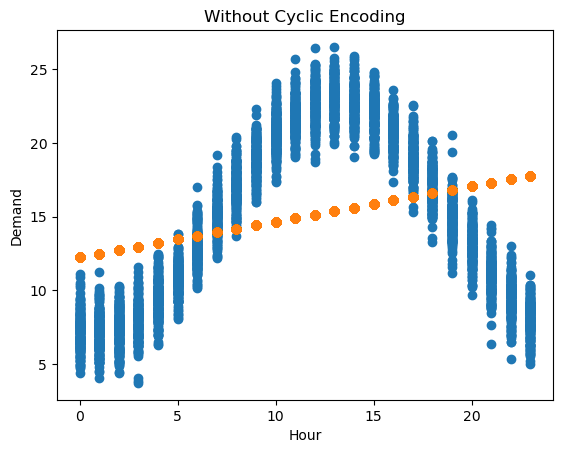

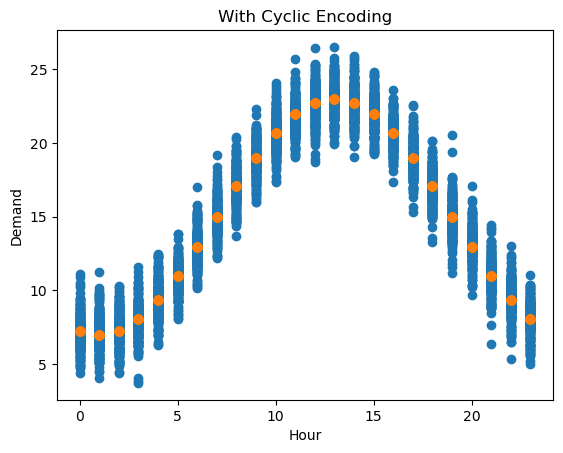

In [22]:
plt.figure()
plt.scatter(X1_test, y_test)
plt.scatter(X1_test, y_pred1)
plt.title("Without Cyclic Encoding")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

plt.figure()
plt.scatter(X1_test, y_test)
plt.scatter(X1_test, y_pred2)
plt.title("With Cyclic Encoding")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

In [ ]:
plt.figure()
plt.scatter(X1_test, y_test)
plt.scatter(X1_test, y_pred2)
plt.title("Without Cyclic Encoding")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.show()

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [24]:
documents = [
    "AI for agriculture using sensors",
    "Smart farming using iot sensors",
    "Deep learning for image recognition",
    "Crop monitoring using AI and iot"
]

vectorizer = TfidfVectorizer()
Tfidf_matrix = vectorizer.fit_transform(documents)

cos_sim = cosine_similarity(Tfidf_matrix)

In [25]:
cos_sim

array([[1.        , 0.29772523, 0.159842  , 0.26378082],
       [0.29772523, 1.        , 0.        , 0.24973562],
       [0.159842  , 0.        , 1.        , 0.        ],
       [0.26378082, 0.24973562, 0.        , 1.        ]])

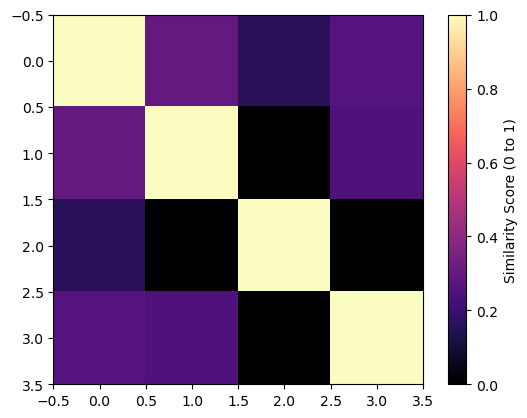

In [26]:
im = plt.imshow(cos_sim, cmap='magma', interpolation='nearest')
plt.colorbar(im, label='Similarity Score (0 to 1)')
plt.show()

slope:  5.750000000000002
angle:  80.13419305691563


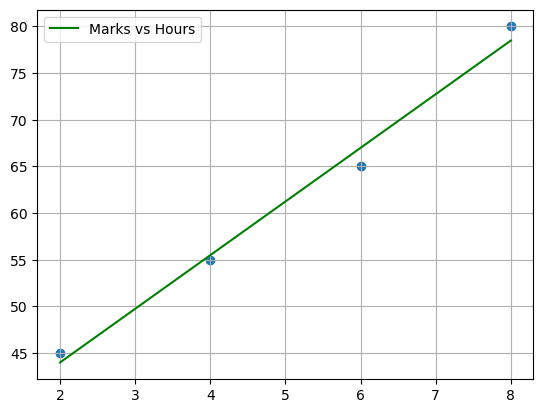

In [27]:
hours = np.array([2, 4, 6, 8])
marks = np.array([45, 55, 65, 80])

slope, intercept = np.polyfit(hours, marks, 1)
theta = np.degrees(np.arctan(slope))

print('slope: ', slope)
print('angle: ', theta)

plt.scatter(hours, marks)
plt.plot(hours, slope * hours + intercept, color='Green', label='Marks vs Hours')
plt.grid()
plt.legend()
plt.show()